In [1]:
# This code works in Python 3.10.6
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import dgl
import random
import torch
from torch import optim
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, Linear, SAGEConv
import torch_geometric.utils.convert
import seaborn as sns
import itertools
import community as community_louvain
import matplotlib.cm as cm
import glob
import warnings
warnings.filterwarnings('ignore')

Create Metagraph

In [2]:
import import_ipynb
import pubmed_dataset

importing Jupyter notebook from pubmed_dataset.ipynb
HeteroData(
  disease={
    x=[454, 200],
    y=[454],
  },
  gene={ x=[13561, 200] },
  chemical={ x=[26522, 200] },
  species={ x=[2863, 200] },
  (gene, to, gene)={ edge_index=[2, 40] },
  (gene, to, disease)={ edge_index=[2, 1] },
  (chemical, to, gene)={ edge_index=[2, 70] },
  (chemical, to, chemical)={ edge_index=[2, 108] },
  (chemical, to, species)={ edge_index=[2, 18] },
  (species, to, gene)={ edge_index=[2, 6] }
)


In [3]:
data = pubmed_dataset.data

In [4]:
dataset = data.clone()
# Node features are removed as a temporary fix to the errors in conversion of 
#Pytorch Geometric HeteroData to DGL graph. Node features are not important for creating metagraph.
dataset['disease'].x = dataset['disease'].x[:405, :]
dataset['disease'].y = dataset['disease'].y[:405]
dataset['gene'].x = dataset['gene'].x[:13499, :]
dataset['chemical'].x = dataset['chemical'].x[:26406, :]
dataset['species'].x = dataset['species'].x[:2741, :]

In [5]:
#Create metagraph
g = torch_geometric.utils.convert.to_dgl(dataset)
meta_g= g.metagraph()

Train PubMed

In [6]:
transform = T.RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)
data = transform(data)
data

HeteroData(
  disease={
    x=[454, 200],
    y=[454],
    train_mask=[454],
    val_mask=[454],
    test_mask=[454],
  },
  gene={ x=[13561, 200] },
  chemical={ x=[26522, 200] },
  species={ x=[2863, 200] },
  (gene, to, gene)={ edge_index=[2, 40] },
  (gene, to, disease)={ edge_index=[2, 1] },
  (chemical, to, gene)={ edge_index=[2, 70] },
  (chemical, to, chemical)={ edge_index=[2, 108] },
  (chemical, to, species)={ edge_index=[2, 18] },
  (species, to, gene)={ edge_index=[2, 6] }
)

In [7]:
class HeteroGNN(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                edge_type: SAGEConv((-1, -1), hidden_channels)
                for edge_type in metadata[1]
            })
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: F.leaky_relu(x) for key, x in x_dict.items()}
        return self.lin(x_dict['disease'])

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    mask = data['disease'].train_mask
    loss = F.cross_entropy(out[mask], data['disease'].y[mask])
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def test():
    model.eval()
    pred = model(data.x_dict, data.edge_index_dict).argmax(dim=-1)

    accs = []
    for split in ['train_mask', 'val_mask', 'test_mask']:
        mask = data['disease'][split]
        acc = (pred[mask] == data['disease'].y[mask]).sum() / mask.sum()
        accs.append(float(acc))
    return accs

In [8]:
def remap_indices(node_list):
    val_list = [*range(0, len(node_list), 1)]
    return dict(zip(node_list,val_list))  

In [9]:
def preprocess_edges(edgelist,node_list):
    res = [[node_list[i] for i, j in edgelist],[node_list[j] for i, j in edgelist]] 
    node_from = torch.tensor(res[0])
    node_to = torch.tensor(res[1])
    edges = torch.concat((node_from,node_to)).reshape(-1,len(node_from))
    return edges

In [10]:
def get_node_type(node_type):
    if node_type == 1:
        return 'disease'
    elif node_type == 0:
        return 'gene'
    elif node_type == 2:
        return 'chemical'
    elif node_type == 3:
        return 'species'

In [11]:
#List of edges in metagraph of PubMed
list(meta_g.edges())

[('chemical', 'chemical'),
 ('chemical', 'gene'),
 ('chemical', 'species'),
 ('gene', 'disease'),
 ('gene', 'gene'),
 ('species', 'gene')]

In [12]:
def create_dataset(nodes,edges,disease_df,gene_df,chemical_df,species_df,node_id,df_graph):
    disease = np.asarray(disease_df.drop(columns=['class']))
    gene = np.asarray(gene_df)
    chemical = np.asarray(chemical_df)
    species = np.asarray(species_df)
    

    x_disease = torch.tensor(disease).to(dtype=torch.float32)
    y_disease = torch.tensor(np.array(disease_df["class"]), dtype=torch.long)
    x_gene = torch.tensor(gene).to(dtype=torch.float32)
    x_chemical = torch.tensor(chemical).to(dtype=torch.float32)
    x_species = torch.tensor(species).to(dtype=torch.float32)
    
    #Edges
    source,dest =list(map(list, zip(*edges)))

    gene_to_gene = []
    gene_to_disease = []
    disease_to_disease = []
    chemical_to_gene = []
    chemical_to_disease = []
    chemical_to_chemical = []
    chemical_to_species = []
    species_to_gene = []
    species_to_disease = []
    species_to_species = []
    remaining_edges = []

    class_dict = {'Gene':0, 'Disease':1, 'Chemical':2,'Species':3}

    for i in range(len(edges)):
        if (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Gene']) and \
        (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Gene']):
                gene_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Gene']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Disease']):
                gene_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Disease']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Disease']):
                disease_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Chemical']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Gene']):
                chemical_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Chemical']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Disease']):
                chemical_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0]== class_dict['Chemical']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Chemical']):
                chemical_to_chemical.append((int(source[i]),int(dest[i])))
                
        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Chemical']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Species']):
                chemical_to_species.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Species']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Gene']):
                species_to_gene.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0] == class_dict['Species']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Disease']):
                species_to_disease.append((int(source[i]),int(dest[i])))

        elif (df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0]== class_dict['Species']) and \
            (df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0] == class_dict['Species']):
                species_to_species.append((int(source[i]),int(dest[i])))

        else:
            #The edges not present in the metagraph  
            source_node_type = get_node_type(df_graph.loc[df_graph['nodeId'] == source[i], 'class'].values[0])
            dest_node_type = get_node_type(df_graph.loc[df_graph['nodeId'] == dest[i], 'class'].values[0])
            remaining_edges.append((source_node_type,dest_node_type))
            #remaining_edges.append((int(source[i]),int(dest[i])))
            
    all_edges[node_id] = [*gene_to_gene,*gene_to_disease,*disease_to_disease,*chemical_to_gene,
                          *chemical_to_disease,*chemical_to_chemical,*chemical_to_species, *species_to_gene, 
                          *species_to_disease, *species_to_species]
            
    disease = list(df_graph[df_graph['class'] == 1]['nodeId'])
    disease = [int(i) for i in disease]
    disease_nodes_mapping = remap_indices(disease)
    
    gene = list(df_graph[df_graph['class'] == 0]['nodeId'])
    gene = [int(i) for i in gene]
    gene_nodes_mapping = remap_indices(gene)
    
    chemical = list(df_graph[df_graph['class'] == 2]['nodeId'])
    chemical = [int(i) for i in chemical]
    chemical_nodes_mapping = remap_indices(chemical)
    
    species = list(df_graph[df_graph['class'] == 3]['nodeId'])
    species = [int(i) for i in species]
    species_nodes_mapping = remap_indices(species)


    node_list = {}
    for d in [disease_nodes_mapping, gene_nodes_mapping, chemical_nodes_mapping,species_nodes_mapping]:
        node_list.update(d)            

    #Create Hetero Data      
    small_graph = HeteroData({'disease':{'x': x_disease, 'y':y_disease}, 'gene':{'x': x_gene},
                              'chemical':{'x': x_chemical}, 'species':{'x': x_species}})

    if gene_to_gene:
        edge_index_gene_gene = preprocess_edges(gene_to_gene,node_list)
        small_graph['gene','to','gene'].edge_index = edge_index_gene_gene
    if gene_to_disease:
        edge_index_gene_disease = preprocess_edges(gene_to_disease,node_list)
        small_graph['gene','to','disease'].edge_index = edge_index_gene_disease
    if disease_to_disease:
        edge_index_disease_disease = preprocess_edges(disease_to_disease,node_list)
        small_graph['disease','to','disease'].edge_index = edge_index_disease_disease
    if chemical_to_gene:
        edge_index_chemical_gene = preprocess_edges(chemical_to_gene,node_list)
        small_graph['chemical','to','gene'].edge_index = edge_index_chemical_gene
    if chemical_to_disease:
        edge_index_chemical_disease = preprocess_edges(chemical_to_disease,node_list)
        small_graph['chemical','to','disease'].edge_index = edge_index_chemical_disease
    if chemical_to_chemical:
        edge_index_chemical_chemical = preprocess_edges(chemical_to_chemical,node_list)
        small_graph['chemical','to','chemical'].edge_index = edge_index_chemical_chemical
    if chemical_to_species:
        edge_index_chemical_species = preprocess_edges(chemical_to_species,node_list)
        small_graph['chemical','to','species'].edge_index = edge_index_chemical_species
    if species_to_gene:
        edge_index_species_gene = preprocess_edges(species_to_gene,node_list)
        small_graph['species','to','gene'].edge_index = edge_index_species_gene
    if species_to_disease:
        edge_index_species_disease = preprocess_edges(species_to_disease,node_list)
        small_graph['species','to','disease'].edge_index = edge_index_species_disease
    if species_to_species:
        edge_index_species_species = preprocess_edges(species_to_species,node_list)
        small_graph['species','to','species'].edge_index = edge_index_species_species

    transform = T.Constant(node_types='conference')
    small_graph = transform(small_graph)
    
    #Removing isolated nodes
    transform = T.Compose([T.remove_isolated_nodes.RemoveIsolatedNodes()])
    small_graph = transform(small_graph)

    #Adding test mask for prediction
    transform = T.RandomNodeSplit(split='train_rest', num_val=0.0, num_test=1.0)
    small_graph = transform(small_graph)
            
    return small_graph, remaining_edges

In [13]:
def evaluate_gnn(small_graph):
    with torch.no_grad():
        model.eval()
        #The pred is not used for accuracy, the softmax is used
        pred = model(small_graph.x_dict, small_graph.edge_index_dict).argmax(dim=-1)
        
        #Getting class prediction probabilities from the softmax layer
        softmax = model(small_graph.x_dict, small_graph.edge_index_dict).softmax(dim=-1)
        
        mask = small_graph['disease'].test_mask
        correct = (pred[mask] == small_graph['disease'].y[mask])
               
        correct_indices = [i for i, x in enumerate(correct.tolist()) if x]
        
        #Taking softmax values of the nodes for which prediction is correct
        softmax_pred_list = [softmax.tolist()[i] for i in correct_indices]
        
        return softmax_pred_list, correct_indices

In [14]:
# def get_real_graph(size):
#     real_graph = nx.Graph()
#     if(size <= 25):
#         real_graph = nx.read_gexf(real_graph_path+'real_G25.gexf')
#     elif(size <= 30):
#         real_graph = nx.read_gexf(real_graph_path+'real_G30.gexf')
#     elif(size <= 35):
#         real_graph = nx.read_gexf(real_graph_path+'real_G35.gexf')
#     elif(size <= 40):
#         real_graph = nx.read_gexf(real_graph_path+'real_G40.gexf')
#     elif(size <= 45):
#         real_graph = nx.read_gexf(real_graph_path+'real_G45.gexf')

#     return real_graph

In [15]:
print('Original no of graphs:',len([name for name in glob.glob('../../sampled_graphs_vae/pubmed/*')]))

Original no of graphs: 1440


In [16]:
avg_max_pred_list = []
max_pred_list = []
graph_dict_list = []
softmax_dict_list = []
nodefeature_dict_list = []
all_edges_list = []
class_graphid_list = []

In [17]:
def get_max_pred(softmax_dict,i):
    #Getting the list of predictions for each class
    prob_class0_dict = {}
    prob_class1_dict = {}
    prob_class2_dict = {}
    prob_class3_dict = {}
    prob_class4_dict = {}
    prob_class5_dict = {}
    prob_class6_dict = {}
    prob_class7_dict = {}
    for nodeid in softmax_dict:
        list0= []
        list1= []
        list2= []
        list3= []
        list4= []
        list5= []
        list6= []
        list7= []
    
        if len(softmax_dict[nodeid]) > 0:
            list0= []
            list1= []
            list2= []
            list3= []
            list4= []
            list5= []
            list6= []
            list7= []
    
            for prob in softmax_dict[nodeid]:        
                list0.append(prob[0])        
                list1.append(prob[1]) 
                list2.append(prob[2]) 
                list3.append(prob[3])
                list4.append(prob[4])
                list5.append(prob[5])
                list6.append(prob[6])
                list7.append(prob[7])
    
         #Taking max probability of all nodes of each class in a graph
        if len(list0) != 0:
            prob_class0_dict[nodeid]=max(list0)
        if len(list1) != 0:
            prob_class1_dict[nodeid]=max(list1)
        if len(list2) != 0:
            prob_class2_dict[nodeid]=max(list2)
        if len(list3) != 0:
            prob_class3_dict[nodeid]=max(list3)
        if len(list4) != 0:
            prob_class4_dict[nodeid]=max(list4)
        if len(list5) != 0:
            prob_class5_dict[nodeid]=max(list5)
        if len(list6) != 0:
            prob_class6_dict[nodeid]=max(list6)
        if len(list7) != 0:
            prob_class7_dict[nodeid]=max(list7)

    max_pred0 = max(prob_class0_dict.values())
    max_pred1 = max(prob_class1_dict.values())
    max_pred2 = max(prob_class2_dict.values())
    max_pred3 = max(prob_class3_dict.values())
    max_pred4 = max(prob_class4_dict.values())
    max_pred5 = max(prob_class5_dict.values())
    max_pred6 = max(prob_class6_dict.values())
    max_pred7 = max(prob_class7_dict.values())

    print('Run'+str(i),max_pred0, max_pred1, max_pred2, max_pred3,max_pred4, max_pred5, max_pred6, max_pred7)
    max_pred_list.append([max_pred0, max_pred1, max_pred2, max_pred3,max_pred4, max_pred5, max_pred6, max_pred7])

    graph_dict_list.append(graph_dict)
    all_edges_list.append(all_edges)
    softmax_dict_list.append(softmax_dict)
    nodefeature_dict_list.append(nodefeature_dict)
    
    avg_max_pred = (max_pred0+max_pred1+max_pred2+max_pred3+max_pred4+max_pred5+max_pred6+max_pred7)/8
    avg_max_pred_list.append(avg_max_pred)
    
    class0_graphid = max(prob_class0_dict, key=prob_class0_dict.get)
    class1_graphid = max(prob_class1_dict, key=prob_class1_dict.get)
    class2_graphid = max(prob_class2_dict, key=prob_class2_dict.get)
    class3_graphid = max(prob_class3_dict, key=prob_class3_dict.get)
    class4_graphid = max(prob_class4_dict, key=prob_class4_dict.get)
    class5_graphid = max(prob_class5_dict, key=prob_class5_dict.get)
    class6_graphid = max(prob_class6_dict, key=prob_class6_dict.get)
    class7_graphid = max(prob_class7_dict, key=prob_class7_dict.get)

    class_graphid_list.append([class0_graphid,class1_graphid,class2_graphid,class3_graphid,class4_graphid,class5_graphid,class6_graphid,class7_graphid])

In [18]:
for i in range(0,10):
    counter=i
    model = HeteroGNN(data.metadata(), hidden_channels=256, out_channels=8,
                      num_layers=4)
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = 'cpu'
    data, model = data.to(device), model.to(device)
    
    with torch.no_grad():  # Initialize lazy modules.
        out = model(data.x_dict, data.edge_index_dict)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.001)

    best_val_acc = 0
    start_patience = patience = 100
    for epoch in range(1, 501):
        loss = train()
        train_acc, val_acc, test_acc = test()
        if epoch%200==0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
              f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')
    
        if best_val_acc <= val_acc:
            patience = start_patience
            best_val_acc = val_acc
        else:
            patience -= 1
    
        if patience <= 0:
            print('Stopping training as validation accuracy did not improve '
                  f'for {start_patience} epochs')
            break
    
    all_edges = {}
    softmax_dict = {}
    nodefeature_dict = {}
    graph_dict = {}
    
    rootdir = '../../sampled_graphs_vae/pubmed/'
    
    #real_graph_path = '../../../approach_2/real_pubmed_graphs/'
    dir_list = []
    for subdir, dirs,files in os.walk(rootdir):
        
        if files:
            graph_path = os.path.join(subdir, files[0])
            class_path = os.path.join(subdir, files[1])       
            feature_path = os.path.join(subdir, files[2])
    
            graph = nx.read_gexf(graph_path)
            filename = os.path.basename(graph_path)
            graph_id= filename.split('.')[0]
                #print(graph_id)
    
            nodeId_list = []
    
            for key, value in graph.nodes(data=True):
                nodeId_list.append(key)
                edges = [e for e in graph.edges]
    
            node_type_list = torch.load(class_path).detach().numpy()
    
            df_graph = pd.DataFrame()
            df_graph["nodeId"] = nodeId_list
            df_graph["class"] = node_type_list
    
    
            df_feature = pd.DataFrame(torch.load(feature_path).detach().numpy())        
            df_feature["class"] = node_type_list
        
            #real_graph = get_real_graph(len(nodeId_list))
    
            # node_label_list = []
    
            # if not (nx.get_node_attributes(real_graph, "class") is None):
            #     node_class = nx.get_node_attributes(real_graph, "class")
            #     node_label_list.append(node_class.get('1'))
    
            disease_node_features = df_feature[df_feature['class'] == 1].drop(['class'], axis = 1)
    
            #if not (None in node_label_list):
                    
            labels = []
            unique_labels = [0,1,2,3]
                    
            for i in range(0,len(disease_node_features)):
                labels.append(random.choice(unique_labels))
    
            disease_node_features['class']= labels
    
            gene_node_features = df_feature[df_feature['class'] == 0].drop(['class'], axis = 1)
            chemical_node_features = df_feature[df_feature['class'] == 2].drop(['class'], axis = 1)
            species_node_features = df_feature[df_feature['class'] == 3].drop(['class'], axis = 1)
    
    
    
            small_graph_data, removed_edges = create_dataset(nodeId_list,edges,
                                        disease_node_features,gene_node_features,
                                        chemical_node_features,species_node_features,graph_id,df_graph)
    
            edge_list = all_edges[graph_id]
            graph = nx.Graph(edge_list)
            if not nx.is_empty(graph) and nx.is_connected(graph):
    
    
                if (small_graph_data['disease'].x.nelement()!=0) and \
                (small_graph_data['chemical','to','chemical']) and \
                (small_graph_data['chemical','to','gene']) and \
                (small_graph_data['chemical','to','species']) and \
                (small_graph_data['gene','to','disease']) and \
                (small_graph_data['gene','to','gene']):

                        
                    softmax, correct_indices = evaluate_gnn(small_graph_data)
                    softmax_dict[graph_id] = softmax
                    nodefeature_dict[graph_id]={'gene':small_graph_data['gene'].x,
                                                    'disease':small_graph_data['disease'].x[correct_indices],
                                                    'chemical':small_graph_data['chemical'].x,
                                                    'species':small_graph_data['species'].x}
                    graph_dict[graph_id]=df_graph

    print("No. of graphs evaluated: ",len(softmax_dict))
    #Getting the list of predictions for each class

    get_max_pred(softmax_dict,counter)  

Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  122
Run0 0.9462277293205261 0.9784760475158691 0.8269861936569214 0.9913039207458496 0.27313360571861267 0.46647846698760986 0.22384001314640045 0.26110124588012695
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  122
Run1 0.9938931465148926 0.998023509979248 0.9608807563781738 0.8143934011459351 0.3429282307624817 0.42802873253822327 0.03583845496177673 0.4111909866333008
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  122
Run2 0.966711699962616 0.9803800582885742 0.6918157339096069 0.9779450297355652 0.3589847981929779 0.40468189120292664 0.0769243836402893 0.2562965154647827
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  122
Run3 0.9971168041229248 0.9997434020042419 0.8739478588104248 0.9874123334884644 0.44966548681259155 0.2734015882015

In [19]:
avg_max_pred_list

[0.6209434028714895,
 0.623147152364254,
 0.5892175137996674,
 0.591302405577153,
 0.5073046451434493,
 0.6128659341484308,
 0.6065282267518342,
 0.6164687401615083,
 0.6734668090939522,
 0.6284430716186762]

In [20]:
np.mean(avg_max_pred_list)

0.6069687901530415

In [21]:
m = max(avg_max_pred_list)
index = avg_max_pred_list.index(m)
index

8

In [22]:
def plot_graph(graphid, max_pred,nodetype,edges,graph):

    classes = []
    G = nx.Graph(edges)
    df_graph = graph_dict[graphid]
    for g in G.nodes():
        #print(g)
        #print(df_graph.loc[g]['class'])
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0] == 0:
            classes.append(0)
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0] == 1:
            classes.append(1)
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0]== 2:
            classes.append(2)
        if df_graph.loc[df_graph['nodeId'] == str(g), 'class'].values[0] == 3:
            classes.append(3)
   
    
    color_class_map = {0: 'blue', 1: 'red', 2: 'darkgreen', 3: 'orange'}
    
    nx.set_node_attributes(G, dict(zip(G.nodes(), classes)), 'class')
    
    print('Number of nodes: ',G.number_of_nodes())
    print('graph id: ',graphid)
    print(f'Max pred probability for class {nodetype} is {max_pred}')

    nx.draw(G, 
    with_labels=False, node_color=[color_class_map[node[1]['class']] 
                        for node in G.nodes(data=True)], 
            node_size=100,
        font_color='black')
    plt.show()

In [23]:
def print_stat_cont_features(df):
    #print('summary',df.describe())
    print('mean',df.stack().mean())
    print('std dev',df.stack().std())

In [24]:
def index_2d(prob_list, v):
    for i, x in enumerate(prob_list):
        if v in x:
            return (i, x.index(v))

In [25]:
def plot_node_feat(imp_feat):

    sns.distplot(imp_feat,color= 'orange',hist= False)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Feature values',fontsize=20)
    plt.ylabel('Density',fontsize=20)

    plt.show() 

In [26]:
class0_graphid = class_graphid_list[index][0]
class1_graphid = class_graphid_list[index][1]
class2_graphid = class_graphid_list[index][2]
class3_graphid = class_graphid_list[index][3]
class4_graphid = class_graphid_list[index][4]
class5_graphid = class_graphid_list[index][5]
class6_graphid = class_graphid_list[index][6]
class7_graphid = class_graphid_list[index][7]

In [27]:
max_pred0 = max_pred_list[index][0]
max_pred1 = max_pred_list[index][1]
max_pred2 = max_pred_list[index][2]
max_pred3 = max_pred_list[index][3]
max_pred4 = max_pred_list[index][4]
max_pred5 = max_pred_list[index][5]
max_pred6 = max_pred_list[index][6]
max_pred7 = max_pred_list[index][7]

In [28]:
all_edges = all_edges_list[index]

In [29]:
graph_dict = graph_dict_list[index]

In [30]:
softmax_dict = softmax_dict_list[index]

In [31]:
nodefeature_dict = nodefeature_dict_list[index]

Plotting explanation graph with node features for each class of Disease node

Node colors:

Gene - Blue

Disease - Red

Chemical - Darkgreen

Species - Orange

Number of nodes:  12
graph id:  sync156570224836_G12
Max pred probability for class 0 is 0.9997455477714539


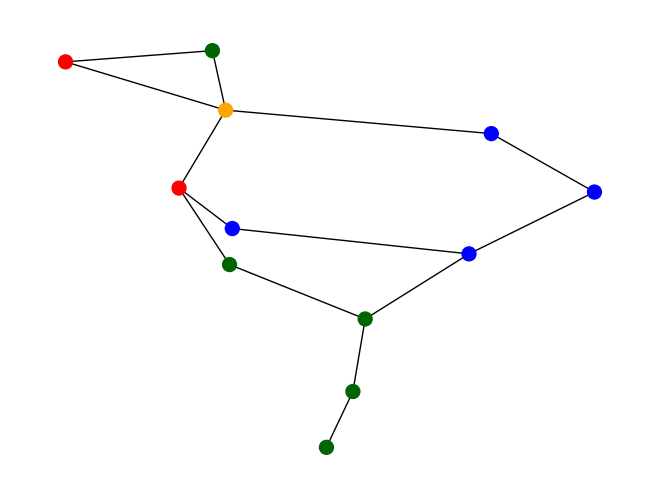

In [32]:
explanation_graph0 = plot_graph(class0_graphid, max_pred0, 0, all_edges[class0_graphid],graph_dict[class0_graphid])

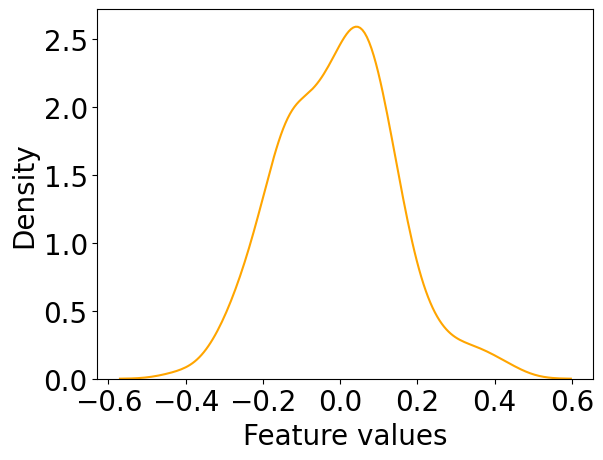

In [33]:
ind = index_2d(softmax_dict[class0_graphid], max_pred0)[0]
disease0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['disease'].numpy()[ind])
plot_node_feat(disease0_df)

In [34]:
print_stat_cont_features(disease0_df)

mean -0.007891387
std dev 0.14974444


Number of nodes:  14
graph id:  sync694772225215_G15
Max pred probability for class 1 is 0.9995187520980835


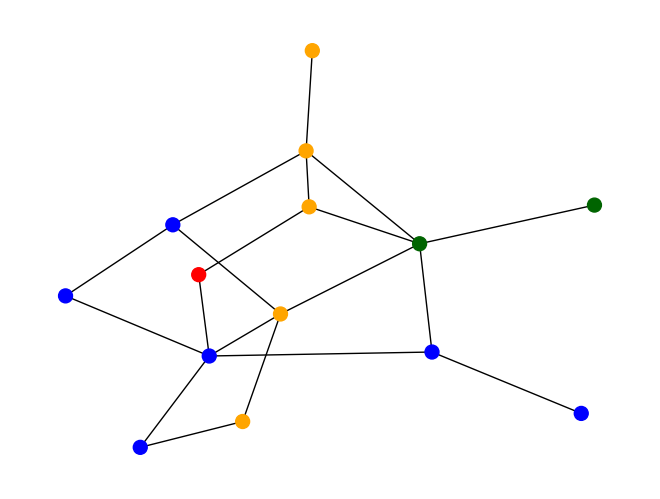

In [35]:
explanation_graph1 = plot_graph(class1_graphid, max_pred1, 1, all_edges[class1_graphid],graph_dict[class1_graphid])

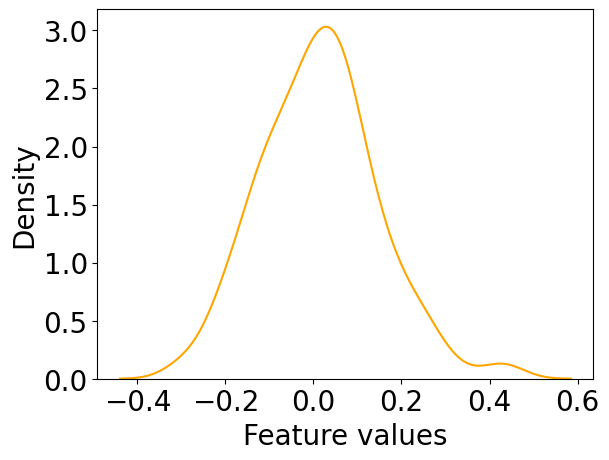

In [36]:
ind = index_2d(softmax_dict[class1_graphid], max_pred1)[0]
disease1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['disease'].numpy()[ind])
plot_node_feat(disease1_df)

In [37]:
print_stat_cont_features(disease1_df)

mean 0.013785311
std dev 0.13342161


Number of nodes:  12
graph id:  sync822493225112_G14
Max pred probability for class 2 is 0.9928024411201477


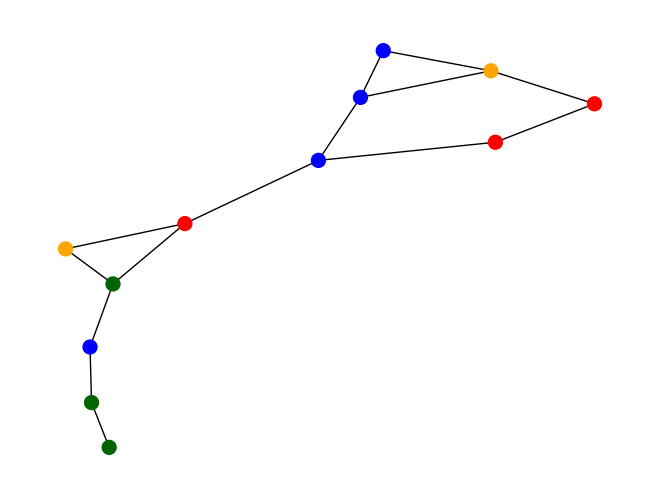

In [38]:
explanation_graph2 = plot_graph(class2_graphid, max_pred2, 2, all_edges[class2_graphid],graph_dict[class2_graphid])

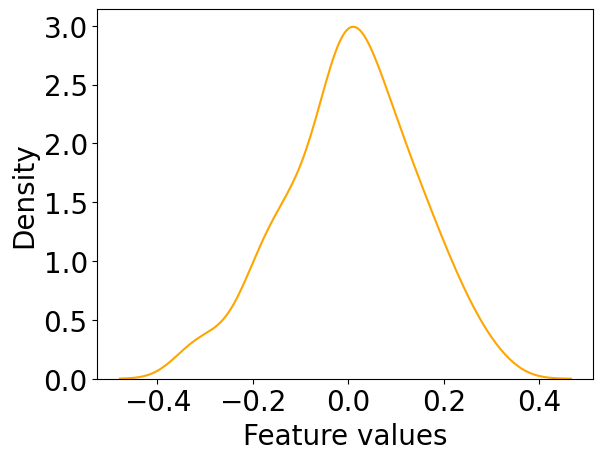

In [39]:
ind = index_2d(softmax_dict[class2_graphid], max_pred2)[0]
disease2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['disease'].numpy()[ind])
plot_node_feat(disease2_df)

In [40]:
print_stat_cont_features(disease2_df)

mean 0.0048658587
std dev 0.13630459


Number of nodes:  12
graph id:  sync327489225106_G14
Max pred probability for class 3 is 0.979019820690155


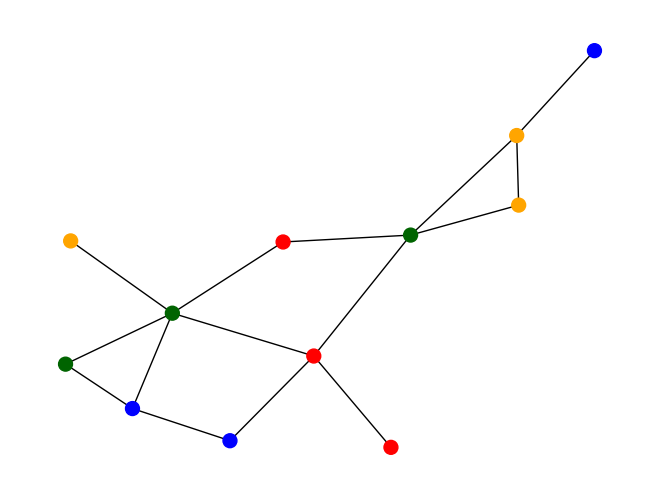

In [41]:
explanation_graph3 = plot_graph(class3_graphid, max_pred3, 3, all_edges[class3_graphid],graph_dict[class3_graphid])

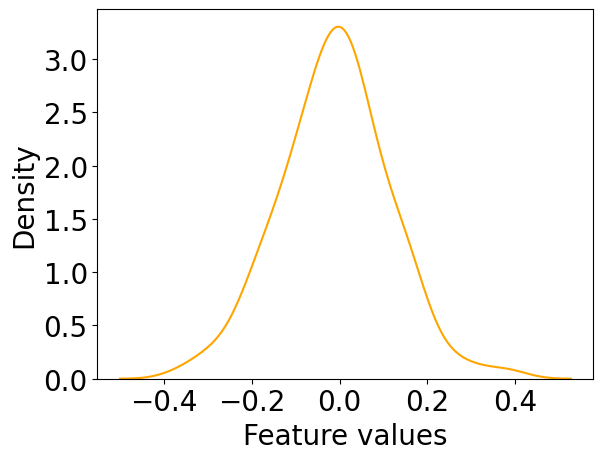

In [42]:
ind = index_2d(softmax_dict[class3_graphid], max_pred3)[0]
disease3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['disease'].numpy()[ind])
plot_node_feat(disease3_df)

In [43]:
print_stat_cont_features(disease3_df)

mean -0.010935173
std dev 0.12572813


Number of nodes:  13
graph id:  sync557412225112_G14
Max pred probability for class 4 is 0.2567652761936188


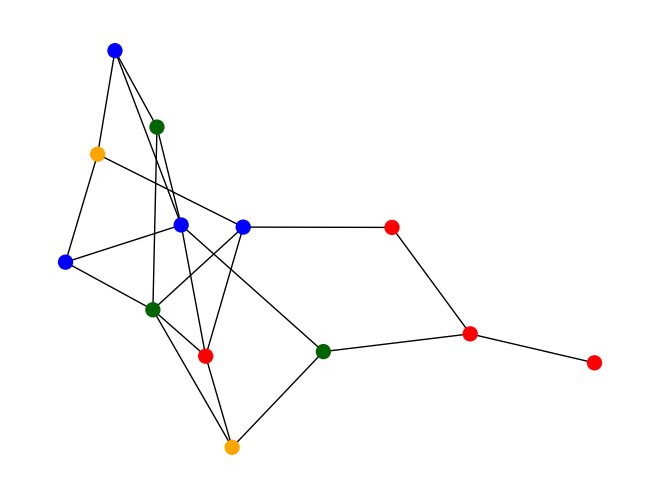

In [44]:
explanation_graph4 = plot_graph(class4_graphid, max_pred4, 4, all_edges[class4_graphid],graph_dict[class4_graphid])

Text(0, 0.5, 'Density')

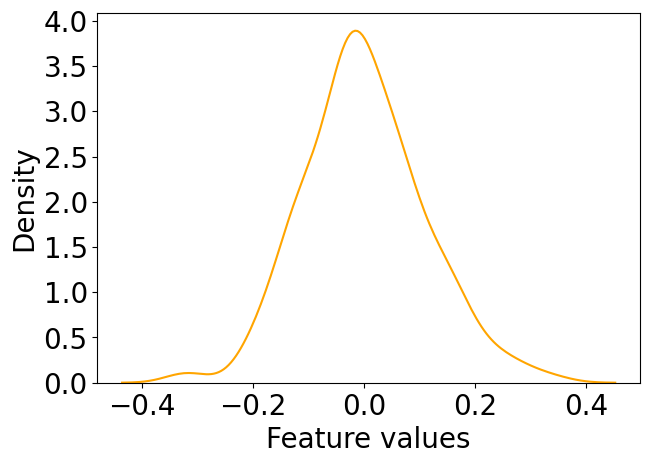

In [45]:
ind = index_2d(softmax_dict[class4_graphid], max_pred4)[0]
disease4_df = pd.DataFrame(nodefeature_dict[class4_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease4_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease4_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [46]:
print_stat_cont_features(disease4_df)

mean 0.00017137408
std dev 0.10870949


Number of nodes:  12
graph id:  sync145580225112_G14
Max pred probability for class 5 is 0.4101218581199646


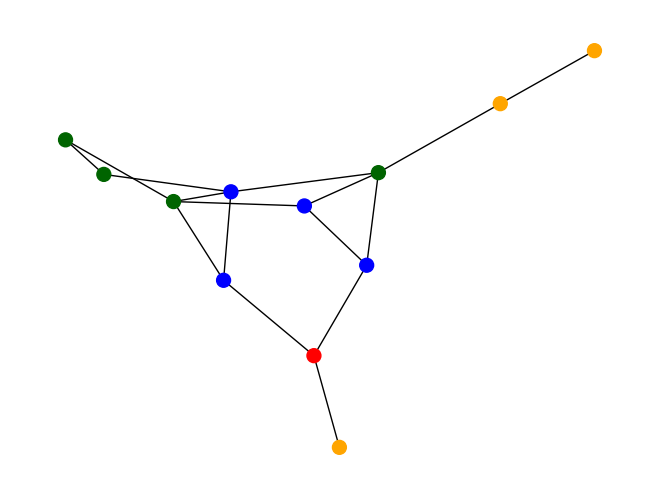

In [47]:
explanation_graph5 = plot_graph(class5_graphid, max_pred5, 5, all_edges[class5_graphid],graph_dict[class5_graphid])

Text(0, 0.5, 'Density')

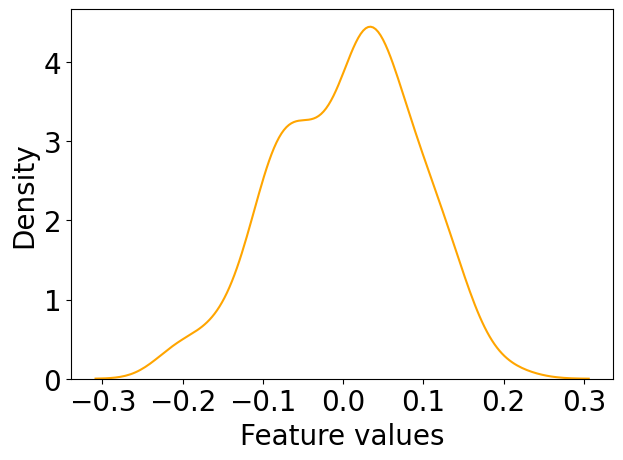

In [48]:
ind = index_2d(softmax_dict[class5_graphid], max_pred5)[0]
disease5_df = pd.DataFrame(nodefeature_dict[class5_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease5_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease5_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [49]:
print_stat_cont_features(disease5_df)

mean 0.00366902
std dev 0.08643673


Number of nodes:  13
graph id:  sync430440224955_G13
Max pred probability for class 6 is 0.39233043789863586


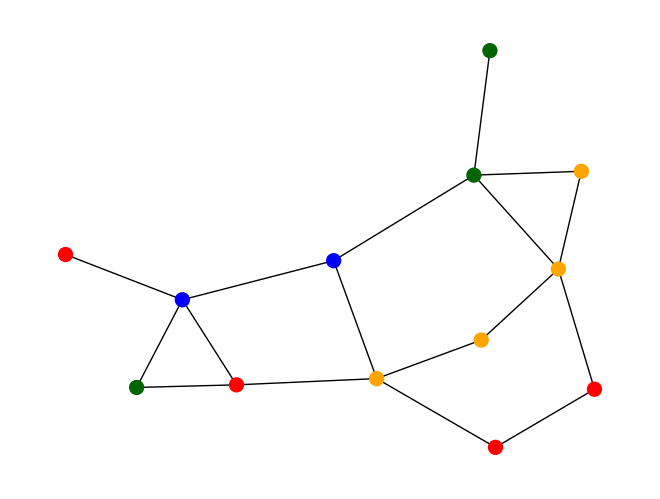

In [50]:
explanation_graph6 = plot_graph(class6_graphid, max_pred6, 6, all_edges[class6_graphid],graph_dict[class6_graphid])

Text(0, 0.5, 'Density')

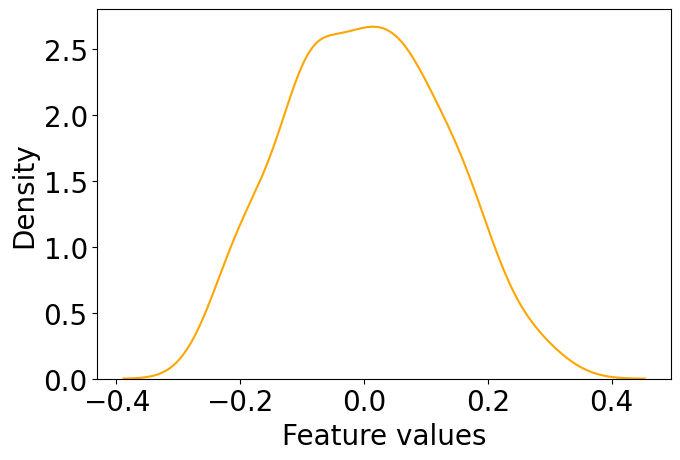

In [51]:
ind = index_2d(softmax_dict[class6_graphid], max_pred6)[0]
disease6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease6_df)
fig, ax = plt.subplots(figsize=(7.4,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease6_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [52]:
print_stat_cont_features(disease6_df)

mean 0.0034231907
std dev 0.1260464


Number of nodes:  14
graph id:  sync164531225048_G14
Max pred probability for class 7 is 0.3574303388595581


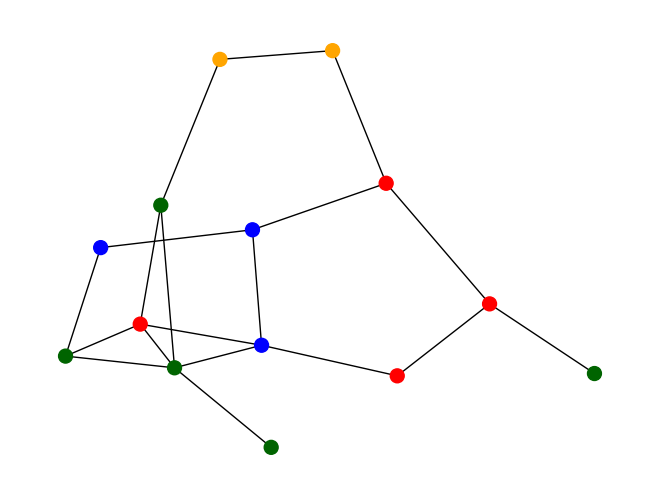

In [53]:
explanation_graph7 = plot_graph(class7_graphid, max_pred7, 7, all_edges[class7_graphid],graph_dict[class7_graphid])

Text(0, 0.5, 'Density')

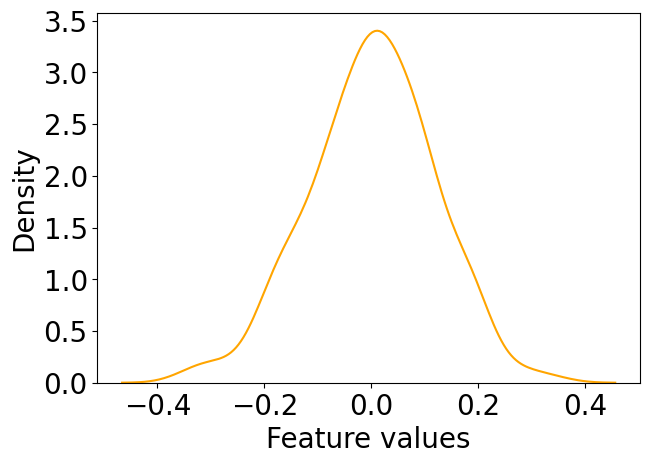

In [54]:
ind = index_2d(softmax_dict[class7_graphid], max_pred7)[0]
disease7_df = pd.DataFrame(nodefeature_dict[class7_graphid]['disease'].numpy()[ind])
#plot_node_feat(disease7_df)
fig, ax = plt.subplots(figsize=(7,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(disease7_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [55]:
print_stat_cont_features(disease7_df)

mean 0.0015433984
std dev 0.11713453


In [56]:
gene6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['gene'].numpy())
print_stat_cont_features(gene6_df)

mean 0.0037532619
std dev 0.121591456


Text(0, 0.5, 'Density')

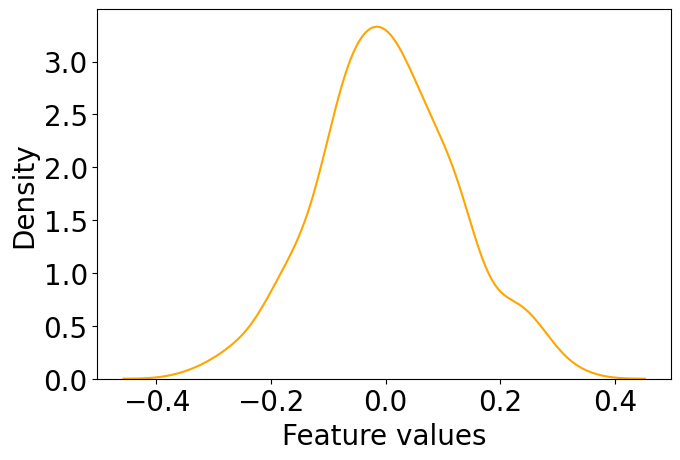

In [57]:
#plot_node_feat(gene6_df)
fig, ax = plt.subplots(figsize=(7.4,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(gene6_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [58]:
chemical6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['chemical'].numpy())
print_stat_cont_features(chemical6_df)

mean 0.0023744758
std dev 0.12781939


Text(0, 0.5, 'Density')

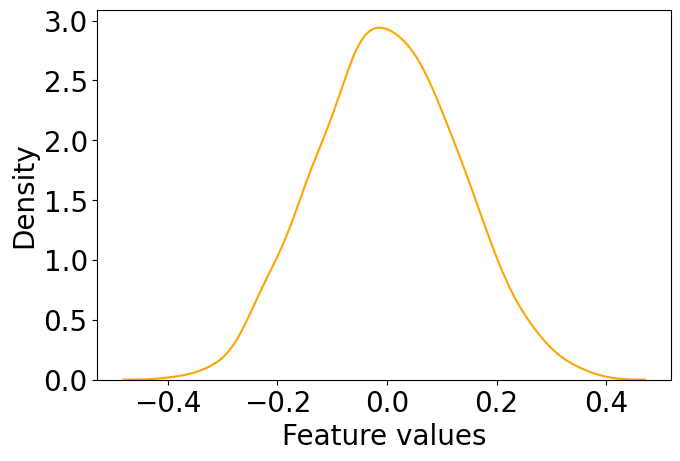

In [59]:
#plot_node_feat(chemical6_df)
fig, ax = plt.subplots(figsize=(7.4,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(chemical6_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [60]:
species6_df = pd.DataFrame(nodefeature_dict[class6_graphid]['species'].numpy())
print_stat_cont_features(species6_df)

mean -0.0042356374
std dev 0.13294214


Text(0, 0.5, 'Density')

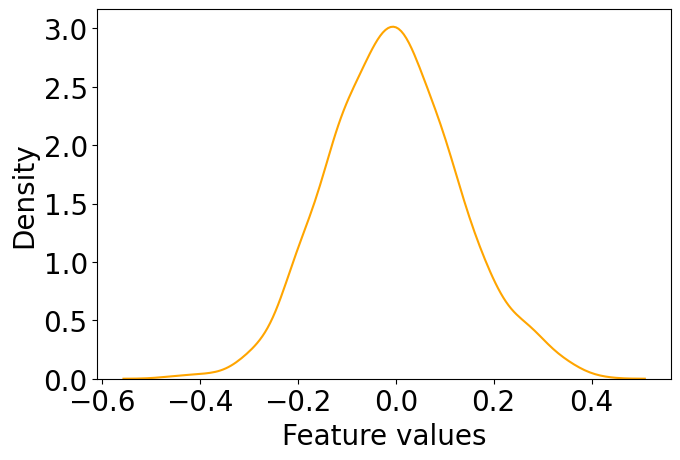

In [61]:
#plot_node_feat(species6_df)
fig, ax = plt.subplots(figsize=(7.4,4.8))
#ax.set_aspect('equal', 'datalim')
sns.distplot(species6_df,color= 'orange',hist= False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feature values',fontsize=20)
plt.ylabel('Density',fontsize=20)

In [62]:
motifs_path = 'motif_pytorch_real/pubmed_10to15/'
files_motif = os.listdir(motifs_path)

## Edit distance

In [63]:
def detect_community(G):
    partition = community_louvain.best_partition(G)

In [64]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/pubmed_10to15/motif_real_10_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_2.gexf
motif_pytorch_real/pubmed_10

In [65]:
#class_graphid_list

In [66]:
def get_avg_edit_distance(graphid_list):
    class_avg_edit_distance = []
    for graphid in graphid_list:
        #print(graphid)
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        detect_community(expln_graph)
        list_com= nx.community.louvain_communities(expln_graph, seed=123)
        H = expln_graph.subgraph(max(list_com, key=len))
        # nx.draw(G,with_labels=True)
        # plt.show()
        edit_dist_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)
            edit_dist = nx.graph_edit_distance(H, motif_graph)
            #print(edit_dist)
            edit_dist_list.append(edit_dist)
        #print('class average', np.mean(edit_dist_list))
        class_avg_edit_distance.append(np.mean(edit_dist_list))
        
    return np.mean(class_avg_edit_distance) 

In [67]:
avg_edit_distance_list = []
for i in range(0,10):
    avg_edit_distance = get_avg_edit_distance(class_graphid_list[i])

    print('Run'+str(i),avg_edit_distance)
    avg_edit_distance_list.append(avg_edit_distance)
print(np.mean(avg_edit_distance_list))

Run0 4.341666666666666
Run1 4.725
Run2 4.108333333333333
Run3 4.258333333333333
Run4 4.616666666666667
Run5 4.066666666666666
Run6 3.9749999999999996
Run7 4.508333333333333
Run8 4.358333333333333
Run9 4.625
4.3583333333333325


## Fidelity

In [68]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/pubmed_10to15/motif_real_10_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_10_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_11_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_2.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_3.gexf
motif_pytorch_real/pubmed_10to15/motif_real_12_4.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_0.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_1.gexf
motif_pytorch_real/pubmed_10to15/motif_real_13_2.gexf
motif_pytorch_real/pubmed_10

In [69]:
def get_avg_fidelity(graphid_list):
    class_avg_fidelity = []
    for graphid in graphid_list:
        expln_graph = nx.Graph(all_edges[graphid])
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        # nx.draw(G,with_labels=True)
        # plt.show()
        fid_score_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)

            GM = nx.algorithms.isomorphism.GraphMatcher(expln_graph,motif_graph)
            x = 1 if GM.subgraph_is_isomorphic() else 0    
            fid_score_list.append(x)

        class_avg_fidelity.append(np.mean(fid_score_list))

    return np.mean(class_avg_fidelity)

In [70]:
avg_fidelity_list = []

for i in range(0,10):
    avg_fidelity = get_avg_fidelity(class_graphid_list[i])

    print('Run'+str(i),avg_fidelity)
    avg_fidelity_list.append(avg_fidelity)
print(np.mean(avg_fidelity_list))

Run0 0.22916666666666669
Run1 0.2875
Run2 0.2958333333333333
Run3 0.32499999999999996
Run4 0.2583333333333333
Run5 0.3125
Run6 0.3125
Run7 0.2708333333333333
Run8 0.2791666666666667
Run9 0.2833333333333333
0.2854166666666666
